<a href="https://colab.research.google.com/github/Ab-126/Machine_Learning/blob/main/End_to_End_ML1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

pathub = kagglehub.dataset_download("somya2115/placement-csv")
print("Path ", pathub)

Using Colab cache for faster access to the 'placement-csv' dataset.
Path  /kaggle/input/placement-csv


In [ ]:
import os
files = os.listdir(pathub)
print("Files in directory:", files)

Files in directory: ['placement.csv']


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
csv_path = os.path.join(pathub, "placement.csv")
df = pd.read_csv(csv_path)
print(df.head())

   Unnamed: 0  cgpa     iq  placement
0           0   6.8  123.0          1
1           1   5.9  106.0          0
2           2   5.3  121.0          0
3           3   7.4  132.0          1
4           4   5.8  142.0          0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [ ]:
# Preprocessing
df = df.iloc[:,1:]
df.head()y

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


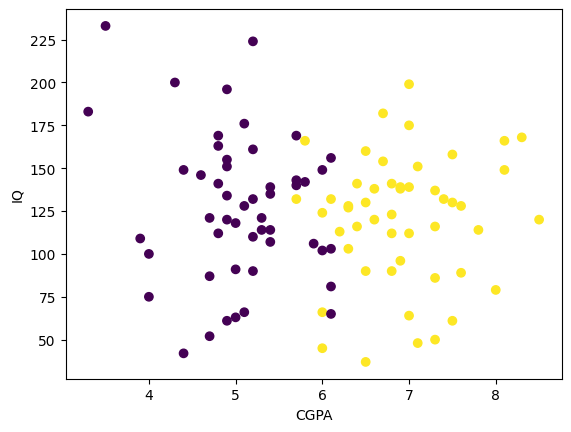

In [ ]:
# Step 1 - Preprocess + EDA + Feature Selection
import matplotlib.pyplot as plt

plt.scatter(df['cgpa'], df['iq'], c=df['placement'])
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.show()

In [ ]:
# Step 2 - Extract Input and Output columns
X = df.iloc[:, 0:2]
Y = df.iloc[:, -1]

In [ ]:
# Step 4 - Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1)

In [ ]:
# Step 3 - Scale the values
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [ ]:
# Step 5 - Train the model
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

# model training
clf.fit(X_train, Y_train)

LogisticRegression()

In [ ]:
# Step 6 - Evaluate the model
y_pred = clf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(Y_test, y_pred)

1.0

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


<Axes: >

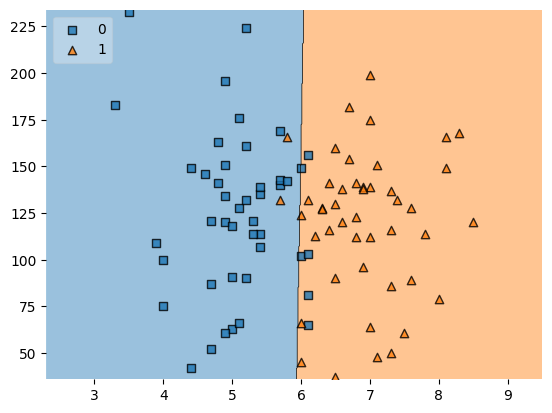

In [ ]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X_train.values, Y_train.values, clf=clf, legend=2)

In [ ]:
# Step 7 - Deploy model on a website
import pickle

pickle.dump(clf, open("model.pkl", "wb"))